In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

base_path = '/Users/huyujie/Documents/amazon-supply-chain-project/data/processed/'
df_amazon = pd.read_csv(base_path + 'train_amazon_features.csv')
df_amazon['OrderDate'] = pd.to_datetime(df_amazon['OrderDate'])

print("数据加载完成，准备开始生成21个可视化图表。")

数据加载完成，准备开始生成21个可视化图表。


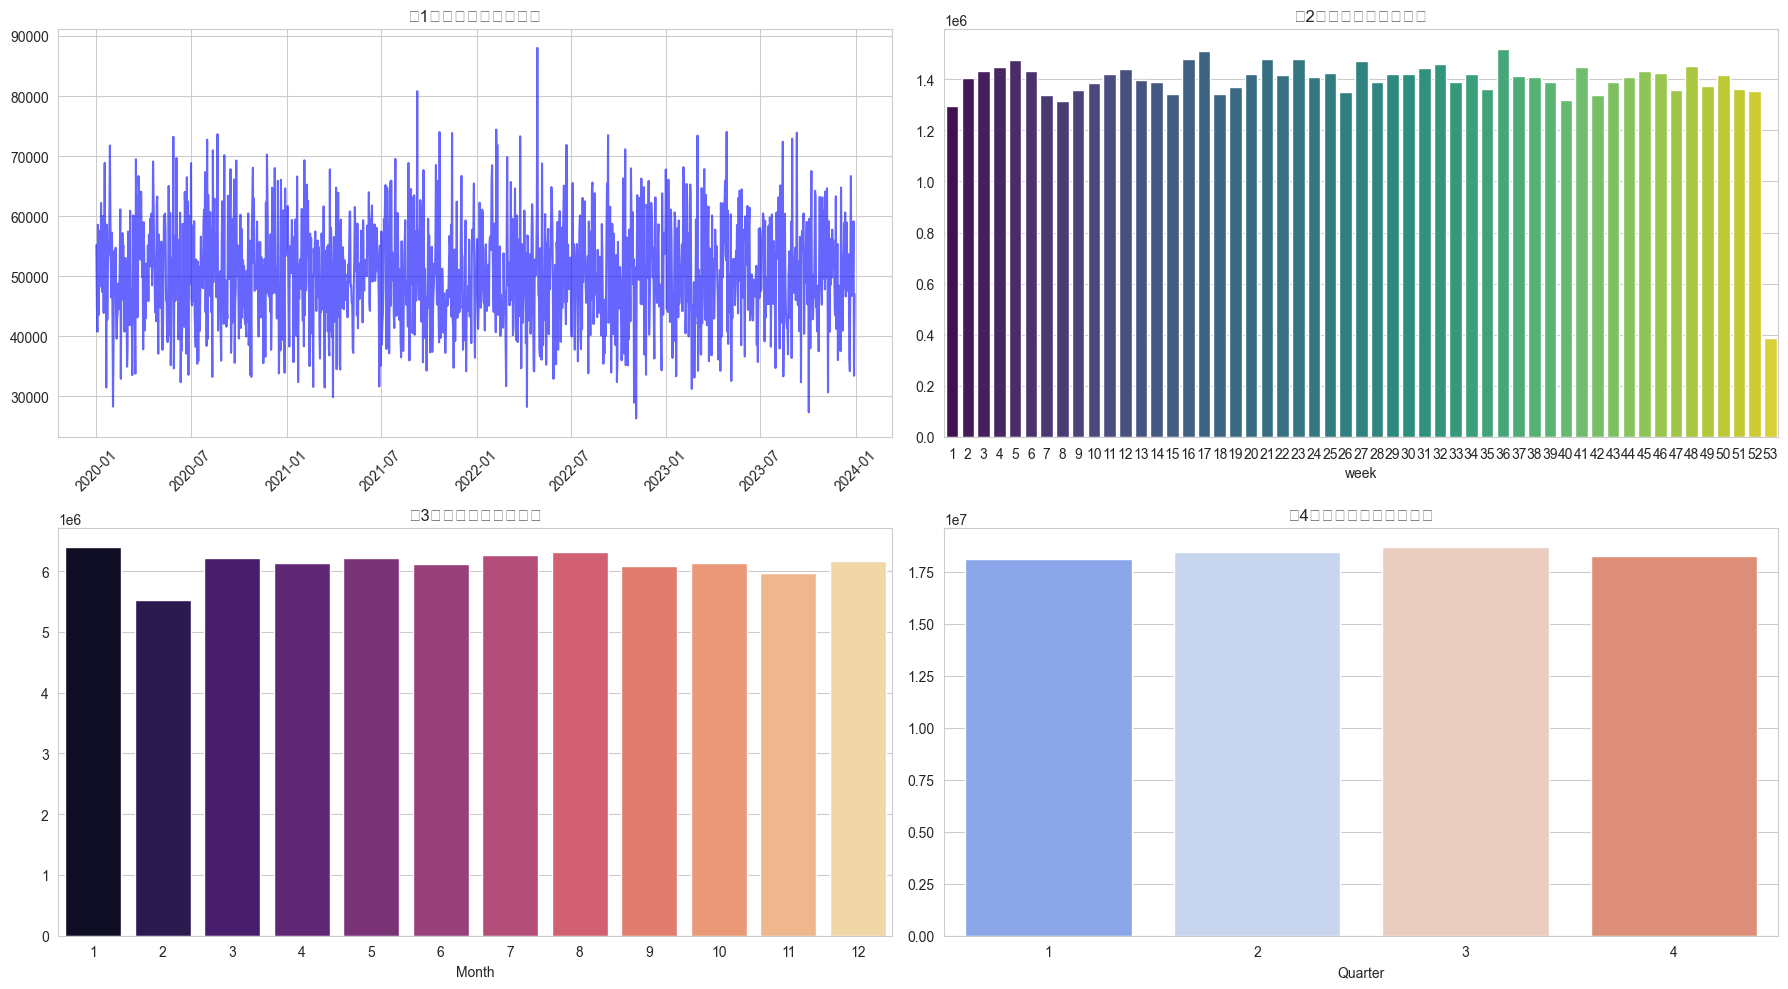

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

daily_sales = df_amazon.groupby(df_amazon['OrderDate'].dt.date)['TotalAmount'].sum()
axes[0, 0].plot(daily_sales.index, daily_sales.values, color='blue', alpha=0.6)
axes[0, 0].set_title('图1：每日总销售额走势')
axes[0, 0].tick_params(axis='x', rotation=45)

weekly_sales = df_amazon.groupby(df_amazon['OrderDate'].dt.isocalendar().week)['TotalAmount'].sum()
sns.barplot(x=weekly_sales.index, y=weekly_sales.values, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('图2：每周总销售额分布')

monthly_sales = df_amazon.groupby('Month')['TotalAmount'].sum()
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('图3：每月总销售额分布')

quarterly_sales = df_amazon.groupby('Quarter')['TotalAmount'].sum()
sns.barplot(x=quarterly_sales.index, y=quarterly_sales.values, ax=axes[1, 1], palette='coolwarm')
axes[1, 1].set_title('图4：每季度总销售额对比')

plt.tight_layout()
plt.show()

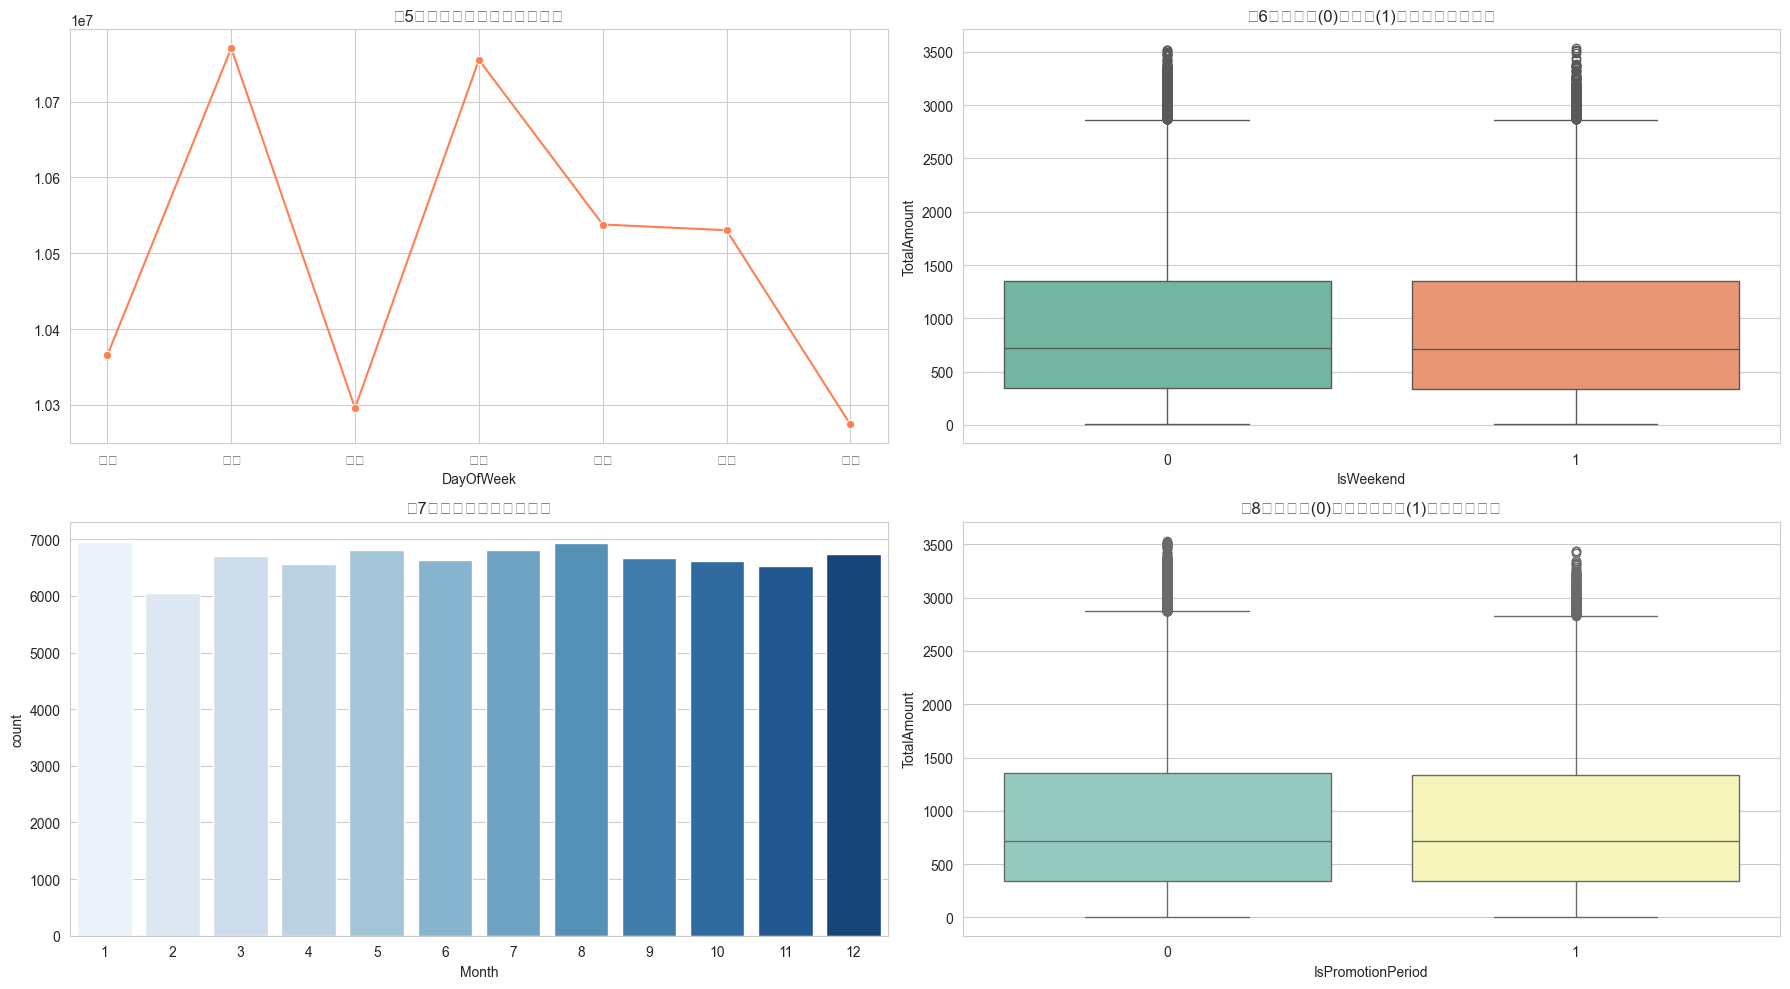

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

weekday_sales = df_amazon.groupby('DayOfWeek')['TotalAmount'].sum()
sns.lineplot(x=weekday_sales.index, y=weekday_sales.values, ax=axes[0, 0], marker='o', color='coral')
axes[0, 0].set_title('图5：一周内各天销售总额趋势')
axes[0, 0].set_xticks(range(7))
axes[0, 0].set_xticklabels(['周一','周二','周三','周四','周五','周六','周日'])

sns.boxplot(x='IsWeekend', y='TotalAmount', data=df_amazon, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('图6：工作日(0)与周末(1)单笔订单金额分布')

sns.countplot(x='Month', data=df_amazon, ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title('图7：各月份订单数量对比')

sns.boxplot(x='IsPromotionPeriod', y='TotalAmount', data=df_amazon, ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('图8：常规期(0)与年底大促期(1)订单金额分布')

plt.tight_layout()
plt.show()

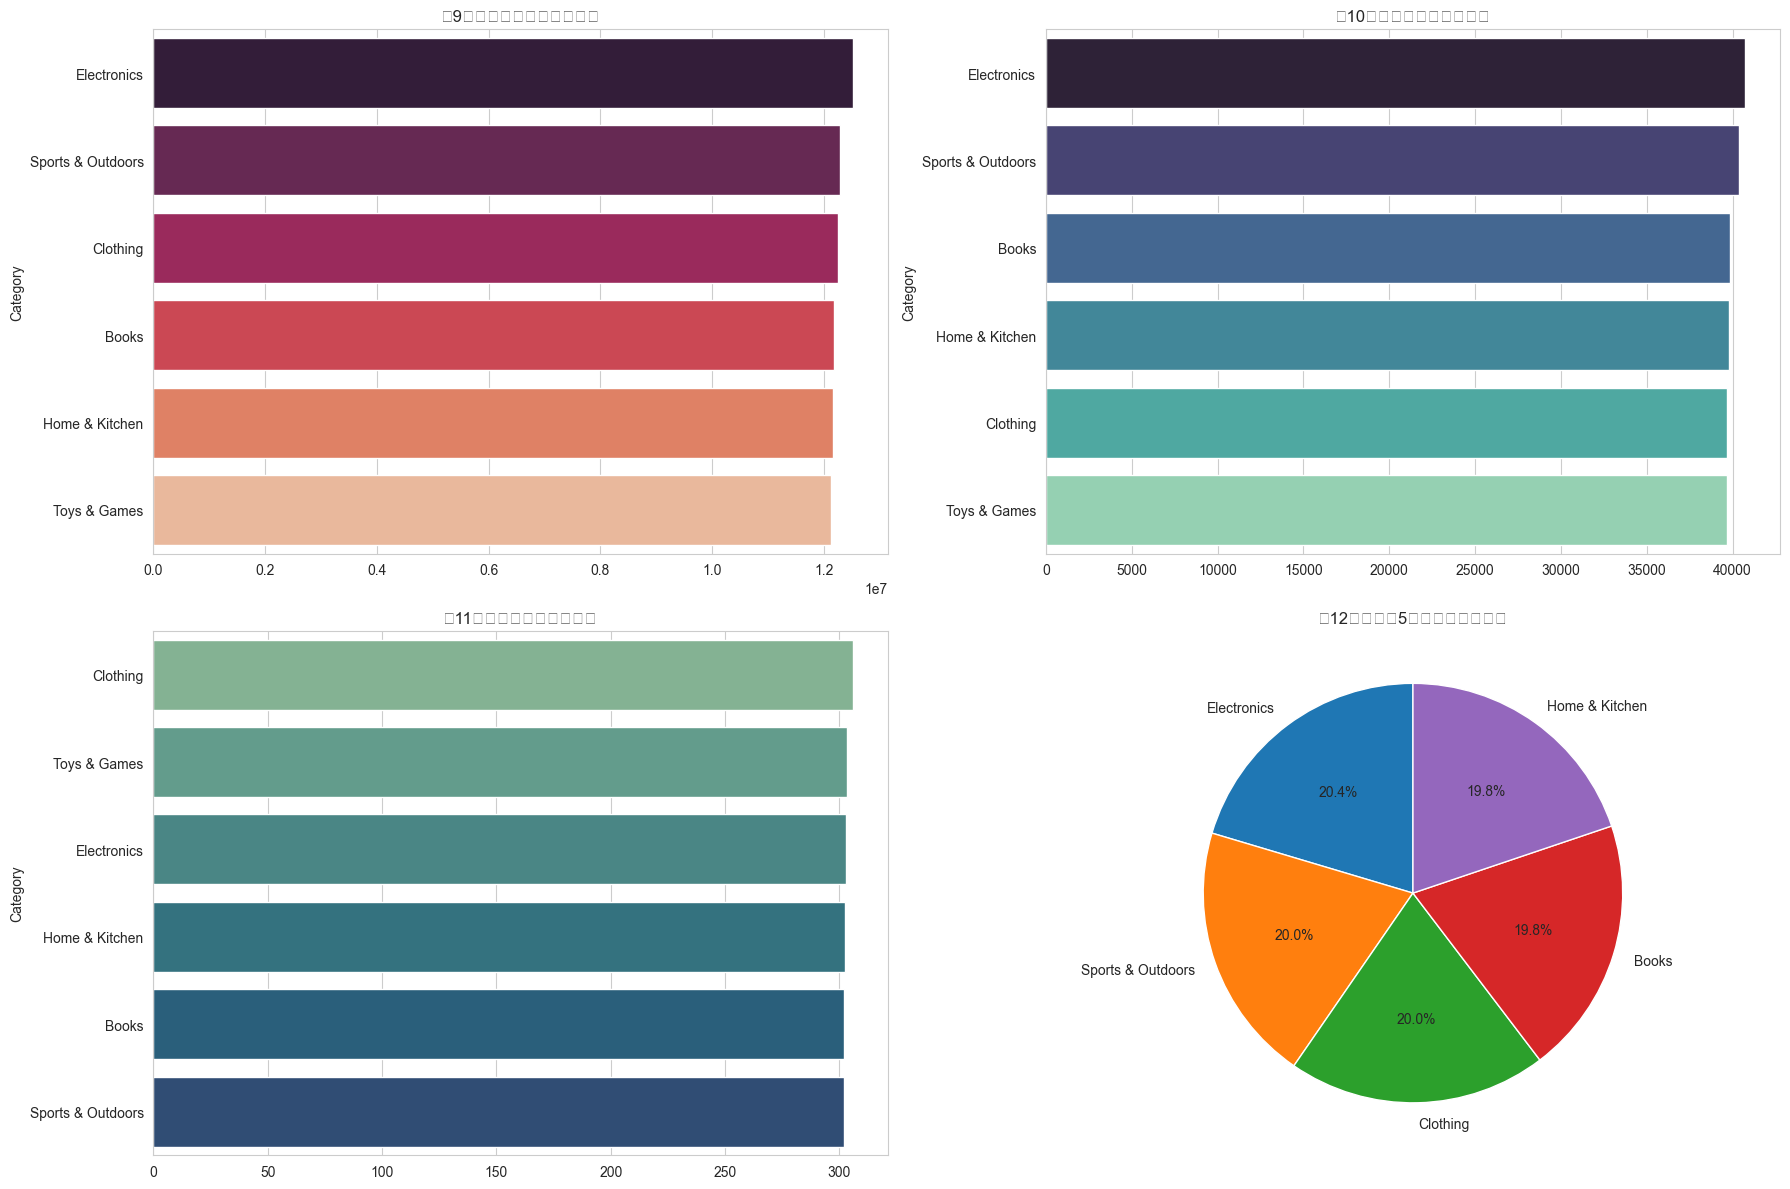

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

cat_sales = df_amazon.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
sns.barplot(x=cat_sales.values, y=cat_sales.index, ax=axes[0, 0], palette='rocket')
axes[0, 0].set_title('图9：各类别总销售额贡献度')

cat_qty = df_amazon.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
sns.barplot(x=cat_qty.values, y=cat_qty.index, ax=axes[0, 1], palette='mako')
axes[0, 1].set_title('图10：各类别总销量贡献度')

cat_price = df_amazon.groupby('Category')['UnitPrice'].mean().sort_values(ascending=False)
sns.barplot(x=cat_price.values, y=cat_price.index, ax=axes[1, 0], palette='crest')
axes[1, 0].set_title('图11：各类别平均单价对比')

axes[1, 1].pie(cat_sales.values[:5], labels=cat_sales.index[:5], autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('图12：头部前5名类别销售额占比')

plt.tight_layout()
plt.show()

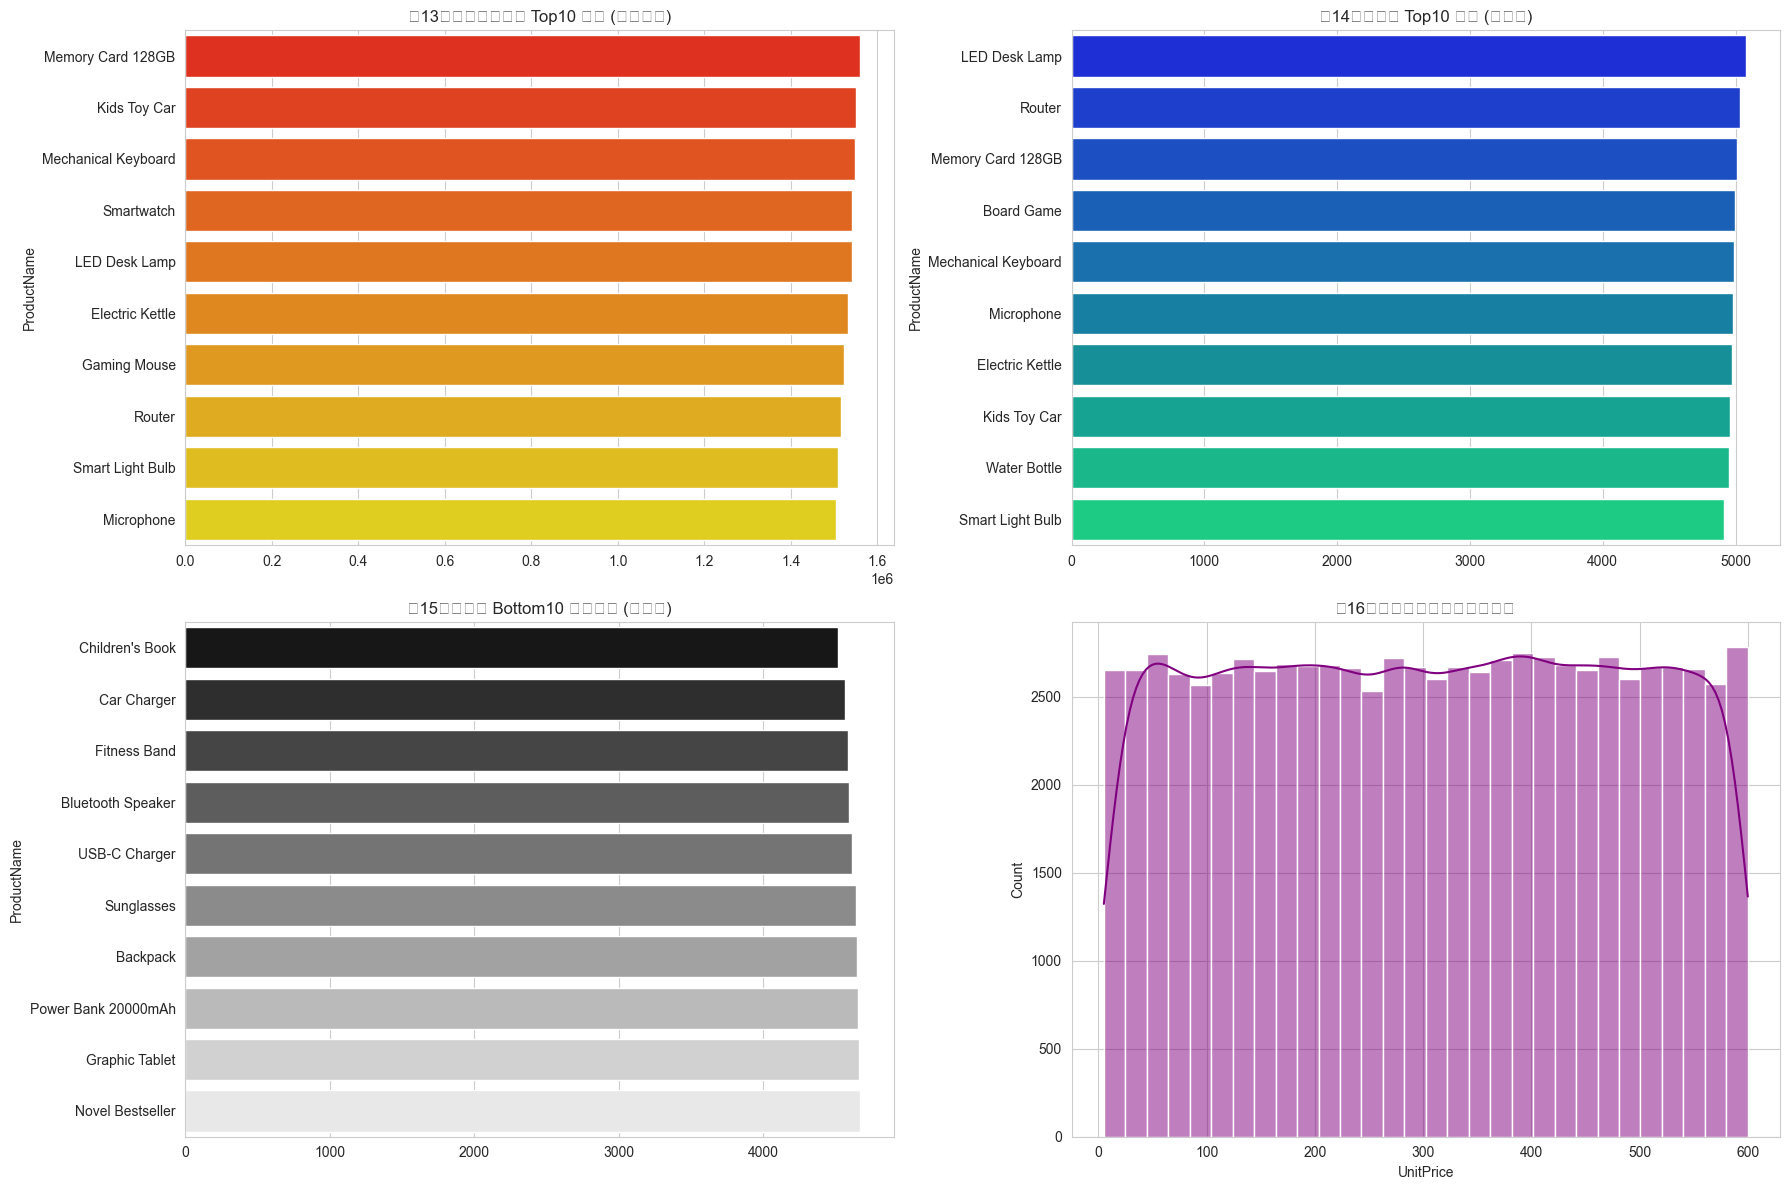

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

top_sales_prod = df_amazon.groupby('ProductName')['TotalAmount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_sales_prod.values, y=top_sales_prod.index, ax=axes[0, 0], palette='autumn')
axes[0, 0].set_title('图13：吸金能力最强 Top10 商品 (按销售额)')

top_qty_prod = df_amazon.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_qty_prod.values, y=top_qty_prod.index, ax=axes[0, 1], palette='winter')
axes[0, 1].set_title('图14：最畅销 Top10 商品 (按销量)')

bottom_qty_prod = df_amazon.groupby('ProductName')['Quantity'].sum().sort_values(ascending=True).head(10)
sns.barplot(x=bottom_qty_prod.values, y=bottom_qty_prod.index, ax=axes[1, 0], palette='gray')
axes[1, 0].set_title('图15：最滞销 Bottom10 商品预警 (按销量)')

sns.histplot(df_amazon['UnitPrice'], bins=30, kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('图16：全站商品单价分布直方图')

plt.tight_layout()
plt.show()

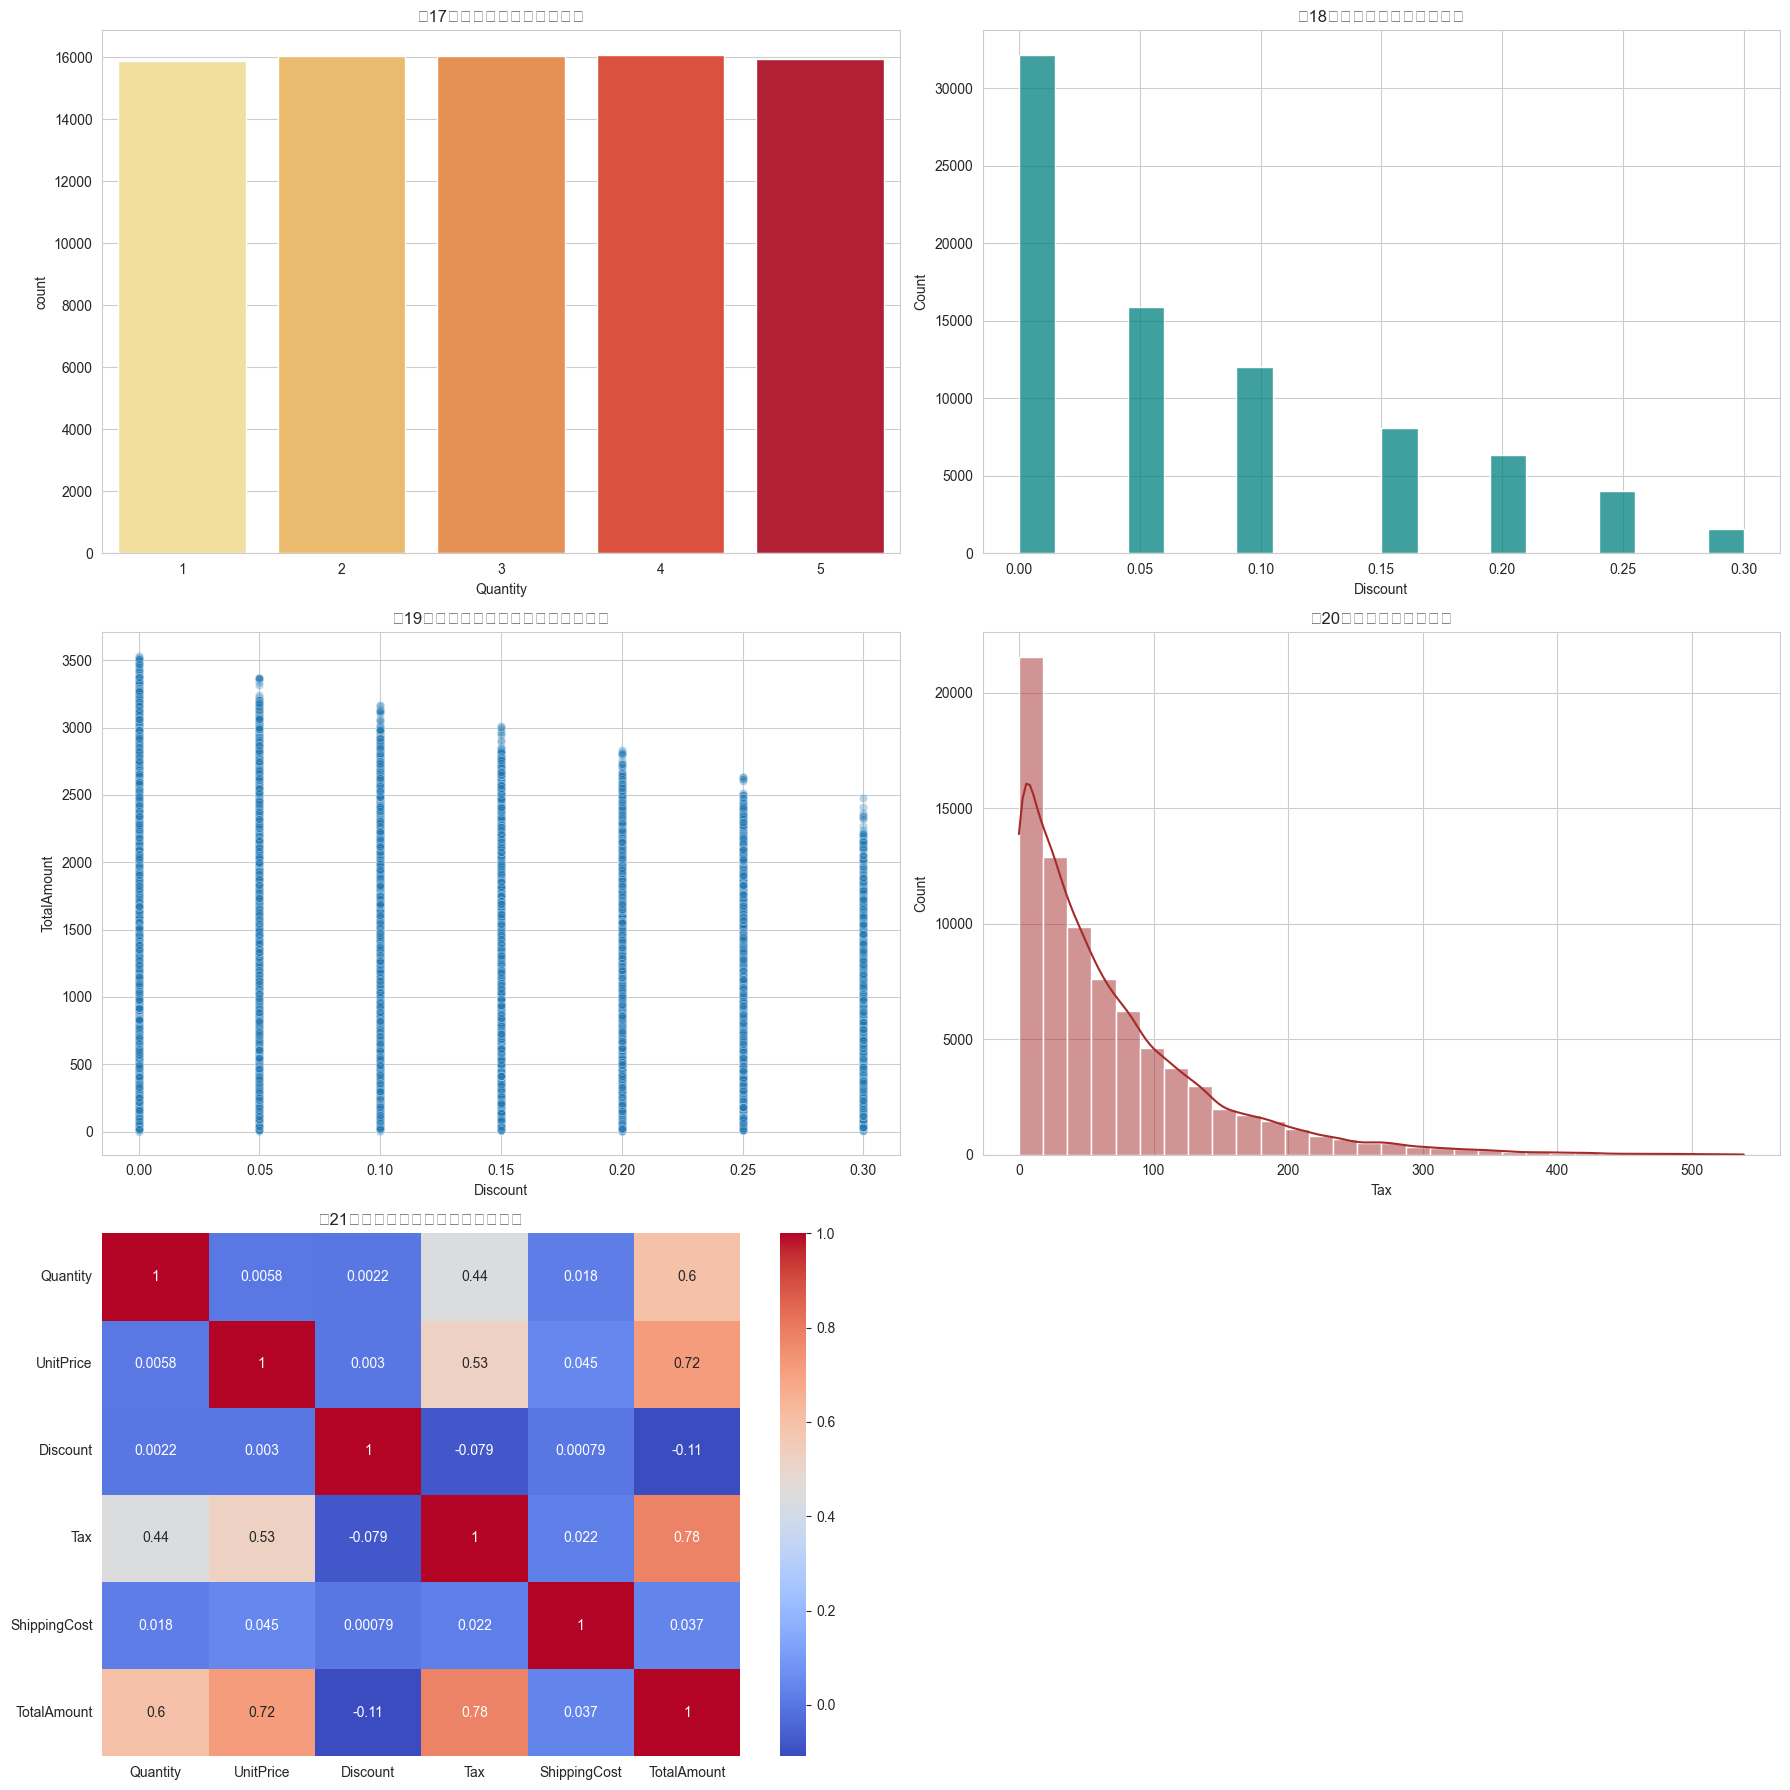

21个可视化图表已全部生成完毕。


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

sns.countplot(x='Quantity', data=df_amazon, ax=axes[0, 0], palette='YlOrRd')
axes[0, 0].set_title('图17：单笔订单购买数量分布')

sns.histplot(df_amazon['Discount'], bins=20, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('图18：订单折扣力度分布情况')

sns.scatterplot(x='Discount', y='TotalAmount', data=df_amazon, ax=axes[1, 0], alpha=0.3)
axes[1, 0].set_title('图19：折扣力度与订单总额的散点关系')

sns.histplot(df_amazon['Tax'], bins=30, kde=True, ax=axes[1, 1], color='brown')
axes[1, 1].set_title('图20：订单税费分布特征')

numeric_cols = df_amazon[['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']]
correlation = numeric_cols.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=axes[2, 0])
axes[2, 0].set_title('图21：数值型特征变量相关性热力图')

fig.delaxes(axes[2, 1])

plt.tight_layout()
plt.show()
print("21个可视化图表已全部生成完毕。")